# Importing Required Libraries

pandas - data handling ,
numpy - numerical operations ,
matplotlib - visualization ,
sklearn - ML model, split, metrics

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error ,mean_squared_error , r2_score

# We load the CSV file containing mutiple records

In [4]:
df = pd.read_csv(r"C:\Users\lenovo\Downloads\salary_data_5000.csv")

In [5]:
df.head(8)

,experience_years,education_level,skill_score,salary
0,6,1,10,53171
1,19,2,1,78726
2,14,2,10,85715
3,10,1,9,57458
4,7,1,1,34385
5,20,3,1,98778
6,6,1,10,47514
7,18,1,8,86886


# Basic Data Understanding (EDA)

In [7]:
df.isnull().sum()

experience_years    0
education_level     0
skill_score         0
salary              0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   experience_years  5000 non-null   int64
 1   education_level   5000 non-null   int64
 2   skill_score       5000 non-null   int64
 3   salary            5000 non-null   int64
dtypes: int64(4)
memory usage: 156.4 KB


In [9]:
df.describe()

,experience_years,education_level,skill_score,salary
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,10.020800,1.642200,5.471600,60303.388200
std,6.094538,0.721861,2.859865,23456.120404
min,0.000000,1.000000,1.000000,-5234.000000
25%,5.000000,1.000000,3.000000,41957.250000
50%,10.000000,1.000000,5.000000,60603.500000
75%,15.000000,2.000000,8.000000,78578.750000
max,20.000000,3.000000,10.000000,124220.000000


# Define Features (X) and Target (y)

In [11]:
X = df[["experience_years" ,"education_level" ,"skill_score"]]
y = df[["salary"]]

# Train–Test Split (80% - training data , 20% - testing data)

In [13]:
X_train , X_test , y_train , y_test = tts(X,y ,test_size=0.2 ,random_state=42)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4000, 3)
(1000, 3)
(4000, 1)
(1000, 1)


# Create and Train Linear Regression Model

In [16]:
LR = LinearRegression()

In [17]:
model = LR.fit(X_train , y_train)

# Making Predictions

In [19]:
y_pred = model.predict(X_test)

# Model Evaluation Metrics
# Mean Absolute Error (MSE)

In [21]:
mae = mean_absolute_error(y_test ,y_pred)
mae

3899.3173931331544

# Mean Squarred Error

In [23]:
mse = mean_squared_error(y_test , y_pred)
mse

23657951.156370826

# Root_Mean_Squarred_Error

In [25]:
rmse = np.sqrt(mse)
rmse

4863.943991903157

# Checking R2 Score

In [27]:
r2 = r2_score(y_test ,y_pred)
r2

0.9555804254169097

# Actual vs Predicted Salary

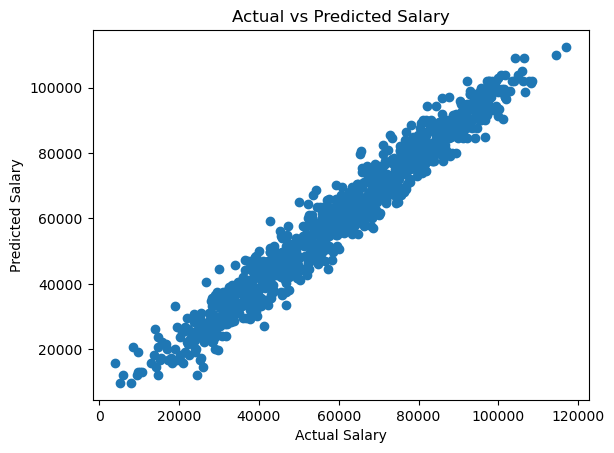

In [29]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")
plt.show()

# Residual Plot (Error Analysis)

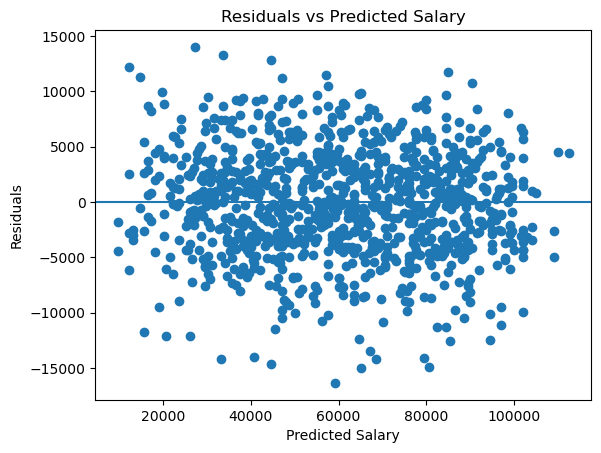

In [31]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Salary")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Salary")
plt.show()

# Distribution of Residuals

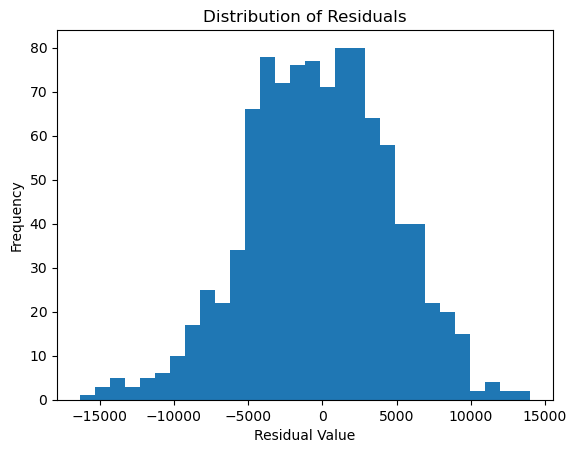

In [33]:
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

# Experience vs Salary (With Regression Insight)

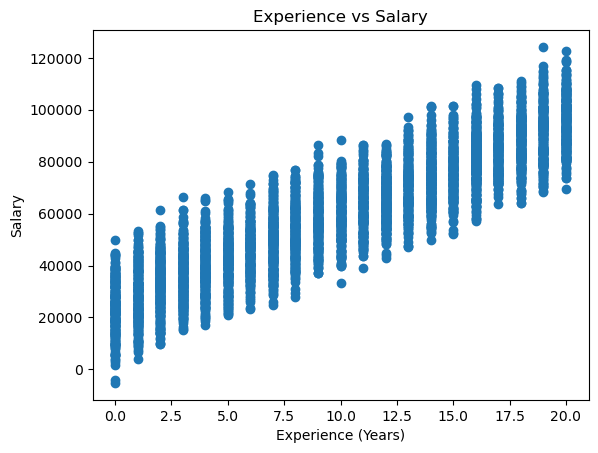

In [35]:
plt.figure()
plt.scatter(df['experience_years'], df['salary'])
plt.xlabel("Experience (Years)")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.show()

# Normalization

In [133]:
from sklearn.preprocessing import  StandardScaler,MinMaxScaler,RobustScaler 
import warnings 
warnings.filterwarnings("ignore")

In [135]:
X = df[['experience_years', 'education_level', 'skill_score']]
y = df['salary']

X_train, X_test, y_train, y_test = tts(
    X, y, test_size=0.2, random_state=42
)

In [137]:
scaler1 = StandardScaler()

In [139]:
scaler1 = scaler1.fit(X_train)

In [141]:
Q_train = scaler1.transform(X_train)

In [143]:
Q_train

array([[-1.47373511, -0.88478524,  1.22050732],
       [ 0.3302026 , -0.88478524, -0.87568387],
       [ 0.3302026 , -0.88478524,  1.22050732],
       ...,
       [-1.47373511,  1.86192873,  0.52177693],
       [ 0.98617994, -0.88478524, -0.17695347],
       [-1.14574643, -0.88478524,  1.56987252]])

In [145]:
pd.DataFrame(Q_train ,  columns=X_train.columns)

,experience_years,education_level,skill_score
0,-1.473735,-0.884785,1.220507
1,0.330203,-0.884785,-0.875684
2,0.330203,-0.884785,1.220507
3,-0.981752,-0.884785,0.871142
4,-0.161780,-0.884785,1.569873
...,...,...,...
3995,0.822186,0.488572,-1.574414
3996,0.002214,-0.884785,0.521777
3997,-1.473735,1.861929,0.521777
3998,0.986180,-0.884785,-0.176953


In [147]:
model = LR.fit(Q_train ,y_train)
model

LinearRegression()

In [149]:
x_test = scaler1.transform(X_test)
y_pred = model.predict(X_test)

In [153]:
score1 = r2_score(y_pred , y_test)
score1

-3.7187367216181784

In [ ]:
# Rmse